# Path Classification

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from scipy.ndimage import median_filter, uniform_filter1d
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from mhealth_activity import Recording

TRAIN_DIR = Path('data/train')
train_files = sorted(TRAIN_DIR.glob('*.pkl'))

def clean_altitude(values, timestamps, max_jump=5.0, smooth_window=5):
    mask = np.ones(len(values), dtype=bool)
    last_valid = values[0]
    for i in range(1, len(values)):
        if abs(values[i] - last_valid) > max_jump:
            mask[i] = False
        else:
            last_valid = values[i]
    return median_filter(values[mask], size=smooth_window), timestamps[mask]

def extract_sensor_features(values, timestamps, prefix, window_sec=50):
    slope, _ = np.polyfit(timestamps, values, 1)
    mid = len(values) // 2
    slope_first,  _ = np.polyfit(timestamps[:mid], values[:mid], 1)
    slope_second, _ = np.polyfit(timestamps[mid:], values[mid:], 1)
    win = max(3, len(values) // 10)
    local_slopes = [
        abs(np.polyfit(timestamps[i:i+win], values[i:i+win], 1)[0])
        for i in range(len(values) - win)
    ]
    min_local_slope = min(local_slopes)
    flattest_pos = np.argmin(local_slopes) / len(local_slopes)
    t0, t_end = timestamps[0], timestamps[-1]
    first_mask = timestamps <= t0 + window_sec
    last_mask  = timestamps >= t_end - window_sec
    first_max = values[first_mask].max() if first_mask.any() else values[0]
    last_min  = values[last_mask].min()  if last_mask.any()  else values[-1]
    return {
        f'{prefix}_start':           values[0],
        f'{prefix}_end':             values[-1],
        f'{prefix}_delta':           values[-1] - values[0],
        f'{prefix}_range':           values.max() - values.min(),
        f'{prefix}_mean':            values.mean(),
        f'{prefix}_slope':           slope,
        f'{prefix}_slope_first':     slope_first,
        f'{prefix}_slope_second':    slope_second,
        f'{prefix}_slope_diff':      slope_second - slope_first,
        f'{prefix}_min_local_slope': min_local_slope,
        f'{prefix}_flattest_pos':    flattest_pos,
        f'{prefix}_window_delta':    last_min - first_max,
    }

def extract_stop_features(rec, stop_std_threshold=0.04, min_stop_sec=3.0):
    ax = rec.data['ax'].values
    ay = rec.data['ay'].values
    az = rec.data['az'].values
    ts = rec.data['ax'].timestamps
    fs = rec.data['ax'].samplerate
    a_mag = np.sqrt(ax**2 + ay**2 + az**2)
    win = max(3, int(fs * 1.0))
    n = len(a_mag)
    rolling_std = np.array([a_mag[max(0, i-win//2): i+win//2+1].std() for i in range(n)])
    is_stopped = rolling_std < stop_std_threshold
    dt = np.diff(ts, prepend=ts[0])
    n_stops, total_stop_dur, longest_stop = 0, 0.0, 0.0
    in_stop, current_dur = False, 0.0
    for i, stopped in enumerate(is_stopped):
        if stopped:
            current_dur += dt[i]; in_stop = True
        else:
            if in_stop and current_dur >= min_stop_sec:
                n_stops += 1; total_stop_dur += current_dur
                longest_stop = max(longest_stop, current_dur)
            in_stop = False; current_dur = 0.0
    if in_stop and current_dur >= min_stop_sec:
        n_stops += 1; total_stop_dur += current_dur
        longest_stop = max(longest_stop, current_dur)
    return {'n_stops': n_stops, 'total_stop_duration': total_stop_dur, 'longest_stop': longest_stop}

def _circ_mean_std(angles_deg):
    rad = np.deg2rad(angles_deg)
    S, C = np.mean(np.sin(rad)), np.mean(np.cos(rad))
    R = np.sqrt(S**2 + C**2)
    mean_dir = np.rad2deg(np.arctan2(S, C)) % 360
    circ_std  = np.rad2deg(np.sqrt(max(0.0, -2 * np.log(R + 1e-10))))
    return mean_dir, circ_std

def _circ_diff(a, b):
    return (a - b + 180) % 360 - 180

def extract_orientation_features(rec, n_segs=8):
    seg_keys = [f'azimuth_s{i}' for i in range(n_segs)]
    diff_keys = [f'azimuth_s{i}_s{i-1}' for i in range(1, n_segs)]
    NAN_KEYS = ['azimuth_mean', 'azimuth_std',
                'azimuth_first_mean', 'azimuth_mid_mean', 'azimuth_last_mean',
                'azimuth_mid_std', 'azimuth_n_turns'] + seg_keys + diff_keys

    azimuth, fs = None, 1.0

    if 'phone_orientationx' in rec.data:
        trace = rec.data['phone_orientationx']
        azimuth = trace.values
        fs = trace.samplerate
        src = 1
    elif 'mx' in rec.data and 'my' in rec.data:
        mx = rec.data['mx'].values
        my = rec.data['my'].values
        azimuth = np.rad2deg(np.arctan2(my, mx)) % 360
        fs = rec.data['mx'].samplerate
        src = 2
    else:
        return {'has_azimuth': 0, **{k: np.nan for k in NAN_KEYS}}

    win = max(3, int(fs * 5))
    s_smooth = uniform_filter1d(np.sin(np.deg2rad(azimuth)), size=win)
    c_smooth = uniform_filter1d(np.cos(np.deg2rad(azimuth)), size=win)
    az_smooth = np.rad2deg(np.arctan2(s_smooth, c_smooth)) % 360

    n = len(az_smooth)
    t1, t2 = n // 3, 2 * n // 3

    mean_all, std_all = _circ_mean_std(az_smooth)
    mean_fst, _       = _circ_mean_std(az_smooth[:t1])
    mean_mid, std_mid = _circ_mean_std(az_smooth[t1:t2])
    mean_lst, _       = _circ_mean_std(az_smooth[t2:])

    edges = [int(n * i / n_segs) for i in range(n_segs + 1)]
    seg_means = [_circ_mean_std(az_smooth[edges[i]:edges[i+1]])[0] for i in range(n_segs)]
    seg_feats = {f'azimuth_s{i}': seg_means[i] for i in range(n_segs)}
    diff_feats = {f'azimuth_s{i}_s{i-1}': _circ_diff(seg_means[i], seg_means[i-1])
                  for i in range(1, n_segs)}

    d_az = np.diff(az_smooth)
    d_az = (d_az + 180) % 360 - 180
    in_turn, n_turns = False, 0
    for da in d_az:
        if abs(da) > 10 and not in_turn:
            in_turn = True; n_turns += 1
        elif abs(da) <= 10:
            in_turn = False

    return {
        'has_azimuth':        src,
        'azimuth_mean':       mean_all,
        'azimuth_std':        std_all,
        'azimuth_first_mean': mean_fst,
        'azimuth_mid_mean':   mean_mid,
        'azimuth_last_mean':  mean_lst,
        'azimuth_mid_std':    std_mid,
        'azimuth_n_turns':    n_turns,
        **seg_feats,
        **diff_feats,
    }

def extract_features(rec):
    features = {}
    features['duration'] = rec.data['ax'].total_time

    pressure_keys = ['pressure_start','pressure_end','pressure_delta','pressure_range',
                     'pressure_mean','pressure_slope','pressure_slope_first',
                     'pressure_slope_second','pressure_slope_diff',
                     'pressure_min_local_slope','pressure_flattest_pos','pressure_window_delta']
    altitude_keys = [k.replace('pressure', 'altitude') for k in pressure_keys]

    if 'phone_pressure' in rec.data:
        p = rec.data['phone_pressure']
        features.update(extract_sensor_features(p.values, p.timestamps, 'pressure'))
        features['has_pressure'] = 1
    else:
        for k in pressure_keys: features[k] = np.nan
        features['has_pressure'] = 0

    if 'altitude' in rec.data:
        a = rec.data['altitude']
        cleaned, ts_clean = clean_altitude(a.values, a.timestamps)
        if len(cleaned) > 1:
            features.update(extract_sensor_features(cleaned, ts_clean, 'altitude'))
        features['has_altitude'] = 1
    else:
        for k in altitude_keys: features[k] = np.nan
        features['has_altitude'] = 0

    features.update(extract_stop_features(rec))
    features.update(extract_orientation_features(rec))

    return features

# Load & cache features

In [3]:
FEATURES_CACHE = 'data/path_features.csv'

if os.path.exists(FEATURES_CACHE):
    X = pd.read_csv(FEATURES_CACHE, index_col=0)
    labels = X.pop('label').values
    print(f"Loaded from cache ({len(X)} recordings)")
else:
    all_features, all_labels = [], []
    for f in train_files:
        r = Recording(str(f))
        all_labels.append(r.labels['path_idx'])
        all_features.append(extract_features(r))
    X = pd.DataFrame(all_features)
    labels = np.array(all_labels)
    X['label'] = labels
    X.to_csv(FEATURES_CACHE)
    X.pop('label')
    print(f"Extracted and cached features ({len(X)} recordings)")

y = labels
print(X.shape)
print(f"NaNs:\n{X.isna().sum()}")
X.head()

KeyboardInterrupt: 

# Train / test split

In [114]:
# No fixed split needed — CV handles evaluation
# We keep a holdout only for final confusion matrix visualization
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.2, random_state=42, stratify=labels
)

# Train & evaluate

/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fit

CV accuracy: 0.841 ± 0.031
Per fold: [0.838 0.848 0.785 0.861 0.873]


/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


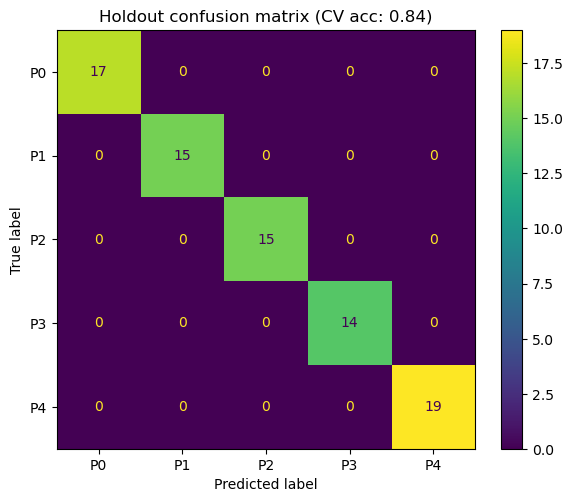

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from lightgbm import LGBMClassifier

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=63,
        random_state=42,
        verbose=-1,
    )),
])

# UNCOMMENT FOR CV CHECK
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# cv_scores = cross_val_score(pipeline, X, labels, cv=cv, scoring='accuracy')
# print(f"CV accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
# print(f"Per fold: {cv_scores.round(3)}")

# Train final model on ALL data for submission
model = pipeline.fit(X, labels)


# Confusion matrix on holdout

# UNCOMMENT FOR CV CHECK
# y_pred = model.predict(X_test)
# fig, ax = plt.subplots(figsize=(6, 5))
# ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=[f'P{i}' for i in range(5)]).plot(ax=ax)
# plt.title(f'Holdout confusion matrix (CV acc: {cv_scores.mean():.2f})')
# plt.tight_layout()
# plt.show()

# Feature importances

Total features: 53

Azimuth features:
azimuth_std           870
azimuth_s7_s6         704
azimuth_s6_s5         600
azimuth_mid_std       581
azimuth_s6            534
azimuth_s4_s3         514
azimuth_s0            512
azimuth_s2_s1         481
azimuth_s5_s4         446
azimuth_first_mean    444
azimuth_mid_mean      412
azimuth_s1            377
azimuth_s1_s0         377
azimuth_s2            362
azimuth_s3            357
azimuth_mean          315
azimuth_s3_s2         313
azimuth_s4            295
azimuth_s5            265
azimuth_last_mean     234
azimuth_s7            229
has_azimuth             0
azimuth_n_turns         0
dtype: int32


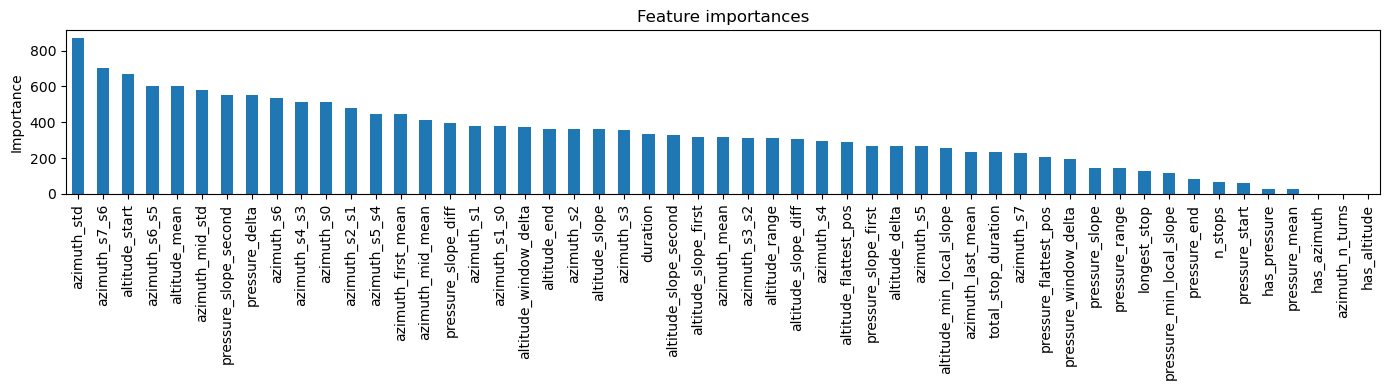

In [116]:
importances = model.named_steps['clf'].feature_importances_
feat_df = pd.Series(importances, index=X.columns).sort_values(ascending=False)

print(f"Total features: {len(feat_df)}")
print("\nAzimuth features:")
print(feat_df[feat_df.index.str.contains('azimuth|has_azimuth', na=False)])

fig, ax = plt.subplots(figsize=(14, 4))
feat_df.plot(kind='bar', ax=ax)
ax.set_title('Feature importances')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.show()

In [117]:
from sklearn.model_selection import cross_val_predict

y_cv_pred = cross_val_predict(pipeline, X, labels, cv=cv)

total_errors = (y_cv_pred != labels).sum()

# Errors involving P0/P1 confusion on either side
p01_errors = ((y_cv_pred != labels) & 
              ((labels <= 1) | (y_cv_pred <= 1))).sum()

# Errors confusing uphill (0,1,2) with downhill (3,4)
uphill = {0, 1, 2}
downhill = {3, 4}
direction_errors = ((y_cv_pred != labels) &
                    (np.isin(labels, list(uphill)) & np.isin(y_cv_pred, list(downhill)) |
                     np.isin(labels, list(downhill)) & np.isin(y_cv_pred, list(uphill)))).sum()

print(f"Total errors:                    {total_errors} / {len(labels)}")
print(f"Errors involving P0 or P1:       {p01_errors} ({100*p01_errors/total_errors:.0f}% of errors)")
print(f"Uphill/downhill direction errors: {direction_errors} ({100*direction_errors/total_errors:.0f}% of errors)")
print(f"Other errors (P2/P3/P4):         {total_errors - p01_errors - direction_errors}")
print()
print(f"Accuracy if P0/P1 solved:        {(len(labels) - (total_errors - p01_errors)) / len(labels):.3f}")
print(f"Accuracy if direction solved too: {(len(labels) - (total_errors - p01_errors - direction_errors)) / len(labels):.3f}")

/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Total errors:                    63 / 396
Errors involving P0 or P1:       46 (73% of errors)
Uphill/downhill direction errors: 7 (11% of errors)
Other errors (P2/P3/P4):         10

Accuracy if P0/P1 solved:        0.957
Accuracy if direction solved too: 0.975


/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# Generate Kaggle submission

In [118]:
import re

TEST_DIR = Path('data/test')
test_files = sorted(TEST_DIR.glob('*.pkl'))

submission = []
for f in test_files:
    rec = Recording(str(f))
    feats = extract_features(rec)
    X_test_kaggle = pd.DataFrame([feats])
    path_pred = model.predict(X_test_kaggle)[0]

    match = re.search(r'(\d{3})\.pkl$', f.name)
    id_ = int(match.group(1))

    submission.append({
        'Id': id_,
        'watch_loc': -1,
        'path_idx': path_pred,
        'standing': -1,
        'walking': -1,
        'running': -1,
        'cycling': -1,
        'step_count': -1,
    })

submission_df = pd.DataFrame(submission, columns=['Id','watch_loc','path_idx','standing','walking','running','cycling','step_count'])
submission_df.to_csv('submission_pathonly.csv', index=False)
print(f"Saved {len(submission_df)} predictions")
print(submission_df['path_idx'].value_counts().sort_index())

/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fit

Saved 280 predictions
path_idx
0    47
1    53
2    52
3    67
4    61
Name: count, dtype: int64


/opt/miniconda3/envs/mhealth/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# Save final path model as joblib artifact

In [ ]:
import joblib


# Save artifact
path_artifact = {
    "model": model,
    "feature_columns": list(X.columns),
    "task": "path_idx",
}

joblib.dump(path_artifact, "group10_model_path.joblib")
print("Saved group10_model_path.joblib")